<a href="https://colab.research.google.com/github/pratham-magar-13/PyTorch-Tutorial/blob/main/PyTorch_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PyTorch Workflow**

In [ ]:
import torch
from torch import nn # nn contains all of PyTorch's  building blocks for neural networks

In [ ]:
import matplotlib.pyplot as plt

# Data (preparing and loading)
Data can be almost anything in machine learning.
* Excel spreadsheet
* Images of nay kind
* Videos
* Audio
* DNA
* Text

# Machine learning is a game of **two parts**:
* Get data into a numercial representation
* Build a model to learn patterns in that numerical representation

To showcase this, lets create some known data using the linear regression formula.
 We will use a linear regression formula to make a straight line with known **parameters**

In [ ]:
# create *known* parameters
weight =0.5
bias=0.3
# create a tensor
start=0
end=1
step=0.02
x=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*x+bias
print(x.ndim)

2


In [ ]:
x,y

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800],
         [0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.3000],
         [0.3100],
         [

In [ ]:
len(x), len(y)

(50, 50)

# Splitting data into training and test sets ( one fo the most important concepts)
Lets create a training and test set with our data.


In [ ]:
# create a train/test split
train_split=int(0.8*len(x))
x_train,y_train=x[:train_split],y[:train_split]
x_test,y_test=x[train_split:],y[train_split:]
len(x_train),len(y_train),len(x_test),len(y_test)

(40, 40, 10, 10)

#how might we better visualize our data?
This is where the data explorer's motto comes in
visualize, visualize, visualize

In [ ]:
def plot_predictions(train_data=x_train,
                      train_labels=y_train,
                      test_data=x_test,
                      test_labels=y_test,
                      predictions=None):
  """
  Plots training data, test data and compares predictions
  """
  plt.figure(figsize=(10,7))

  # plot training data in blue
  plt.scatter(train_data,train_labels,c="b",s=4,label="training data")

  # plot test data in green
  plt.scatter(test_data,test_labels,c="g",s=4,label="test data")

  # are there predictions?
  if predictions is not None:
    # plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data,predictions,c="r",s=4,label="predictions")

  # show the legend
  plt.legend(prop={"size":20})

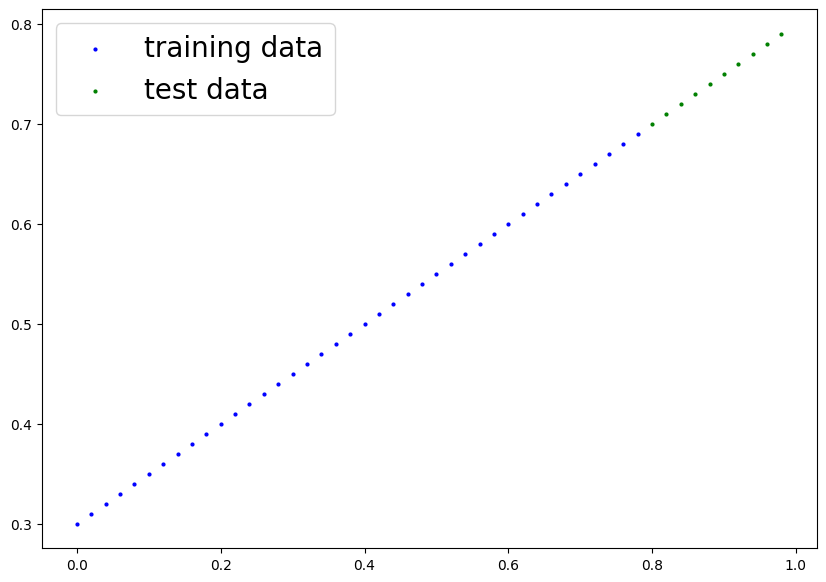

In [ ]:
plot_predictions()

# Build model

Our first PyTorch model

**What our model does:**
* Start with random values( weight and bias)
* Look at training data and adjust the random values to better represent (or get close to ) the ideal values (the weight and bias values we used to create the data)

**how does it do so?**

1. Gradient descent
2. Backpropagation


In [ ]:
# Create linear regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch inherits from nn.Module
  def __init__(self):
    super().__init__()
    # create a linear layer
    self.weights=nn.Parameter(torch.randn(1,
                                          requires_grad=True,
                                          dtype=torch.float))
    self.bias=nn.Parameter(torch.randn(1,
                                       requires_grad=True,
                                       dtype=torch.float))
    #Forward method to define the computation in the model
  def forward(self,x:torch.Tensor)->torch.Tensor: # <- "x" is the input data
      return self.weights*x+self.bias # this is the linear regression formula

### Pytorch model building essentials
* torch.nn - contains all the building blocks for computational graphs ( a neural network can be considered as computational graph)
* torch.nn.Parameter - what parameters our model try and learn, often a Pytorch layer from torch.nn will set these for us
* torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward.
* torch.optim - this where the optimizer in PyTorch live, they will help with gradient descent
* def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation.

 ### Checking the contents of the model
 Now we've created a model, let's see what's inside

So we can check our model parameters or what's inside our model using `.parameters()`.

In [ ]:
# create a random seed
torch.manual_seed(42)

# create an instance of the model ( this is a subclass of a nn.Module)
model_0=LinearRegressionModel()
model_0

# check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using `torch.inference_mode()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `x_test`

When we pass data through our model, its going to run it through the `forward` method

In [ ]:
#  Make preditions with modle
with torch.inference_mode():
  y_preds=model_0(x_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

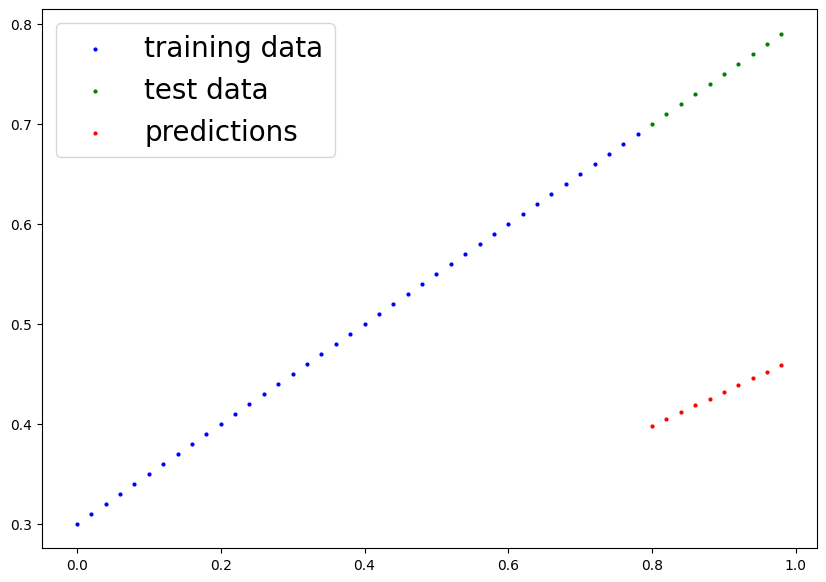

In [ ]:
plot_predictions(predictions=y_preds)

### Train Model

The whole idea of training is for a model to move from some *unknown* parameters (these may be random) to some *known* parameters.

ONe way to measure how poor or how wrong your models predictions are is to use a loss function.

**Loss function , cost function or a criterion**: A function to measure how wrong you model's predictions are to the ideal outputs, lower is better.

**Optimizer**: Takes in to account the loss of a model and adjusts the model's parameters(eg weight and bias)

In [ ]:
# setup a loss function
loss_fn=nn.L1Loss()

# setup an optimizer
optimizer=torch.optim.SGD(params=model_0.parameters(),
                          lr=0.01)

#Building a training loop and a testing loop in PyTorch
A couple of things we need in a training loop:

0. Loop through the data
1. Forward pass( this involves data moving through our model's `forward()` functions)
2. Calculate the loss(compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients (**back propagation**)
5. Optimizer step - adjust the parameters by the gradients calculated by the optimizer (**gradient descent**)

In [ ]:
# an epoch is one loop throught the data
epochs=100

# Track different values
epoch_count=[]
loss_values=[]
test_values=[]

##Training
#0. Loop through the data

for epoch in range(epochs):
  model_0.train() #train mode sets all parameters that require gradients to require gradients

  # 1. Forward pass
  y_pred=model_0(x_train)

  # 2. Calculate the loss
  loss=loss_fn(y_pred,y_train)
  print(f"Loss: {loss}")

  #3 Optimizer zero grad
  # Zero the gradients of the optimizer( they accumulate by default)
  optimizer.zero_grad()

  #4 Perform backpropagation on the loss wrt to paramerters of the model or Loss backward
  loss.backward()

  #5 Optimizer step (perform gradient descent)
  optimizer.step()

  ### Testing
  model_0.eval() #turns off different setting in the model not needed for evaluation/testing

  with torch.inference_mode(): # turns off gradient tracking and couple more things behind the scenes
    # 1. Forward pass
    test_pred=model_0(x_test)
    # 2. Calculate the loss
    test_loss=loss_fn(test_pred,y_test)
    # Print out what's happening
    if epoch %10==0:
      epoch_count.append(epoch)
      loss_values.append(loss)
      test_values.append(test_loss)
      print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
  #print out model state_dict()
  print(model_0.state_dict())

Loss: 0.23488135635852814
Epoch: 0 | Loss: 0.23488135635852814 | Test loss: 0.30306515097618103
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Loss: 0.2233603447675705
OrderedDict({'weights': tensor([0.3445]), 'bias': tensor([0.1488])})
Loss: 0.21183934807777405
OrderedDict({'weights': tensor([0.3484]), 'bias': tensor([0.1588])})
Loss: 0.2003183364868164
OrderedDict({'weights': tensor([0.3523]), 'bias': tensor([0.1688])})
Loss: 0.18879733979701996
OrderedDict({'weights': tensor([0.3562]), 'bias': tensor([0.1788])})
Loss: 0.1772763431072235
OrderedDict({'weights': tensor([0.3601]), 'bias': tensor([0.1888])})
Loss: 0.16575536131858826
OrderedDict({'weights': tensor([0.3640]), 'bias': tensor([0.1988])})
Loss: 0.15423434972763062
OrderedDict({'weights': tensor([0.3679]), 'bias': tensor([0.2088])})
Loss: 0.14271333813667297
OrderedDict({'weights': tensor([0.3718]), 'bias': tensor([0.2188])})
Loss: 0.13119234144687653
OrderedDict({'weights': tensor([0.3757]), 'bias': te

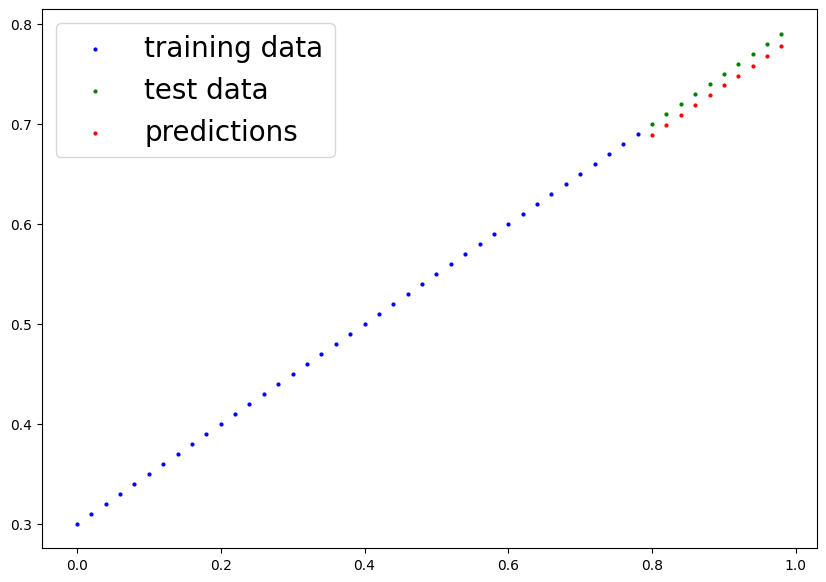

In [ ]:
with torch.inference_mode():
  y_preds_new=model_0(x_test)
plot_predictions(predictions=y_preds_new)

In [ ]:
loss_values, test_values

([tensor(0.2349, grad_fn=<MeanBackward0>),
  tensor(0.1197, grad_fn=<MeanBackward0>),
  tensor(0.0193, grad_fn=<MeanBackward0>),
  tensor(0.0129, grad_fn=<MeanBackward0>),
  tensor(0.0094, grad_fn=<MeanBackward0>),
  tensor(0.0060, grad_fn=<MeanBackward0>),
  tensor(0.0026, grad_fn=<MeanBackward0>),
  tensor(0.0083, grad_fn=<MeanBackward0>),
  tensor(0.0083, grad_fn=<MeanBackward0>),
  tensor(0.0083, grad_fn=<MeanBackward0>)],
 [tensor(0.3031),
  tensor(0.1684),
  tensor(0.0488),
  tensor(0.0292),
  tensor(0.0216),
  tensor(0.0133),
  tensor(0.0050),
  tensor(0.0019),
  tensor(0.0019),
  tensor(0.0019)])

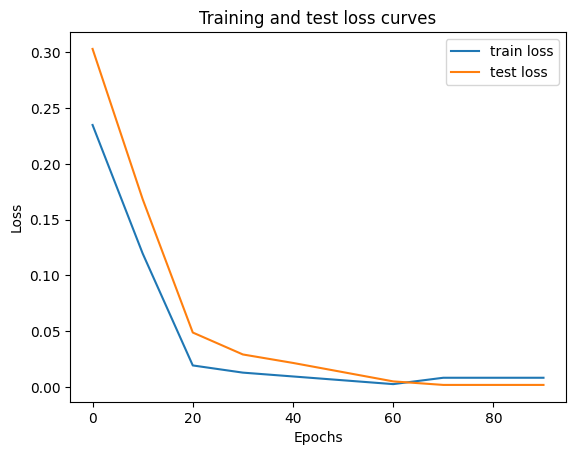

In [ ]:
# plot the loss curves
import numpy as np

plt.plot(epoch_count,np.array(torch.tensor(loss_values).numpy()),label="train loss")
plt.plot(epoch_count,np.array(torch.tensor(test_values).numpy()),label="test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

# Saving a model in PyTorch
There are three main methods for savin and loading models in PyTorch.
1. `torch.save()` - allows you to save a PyTorch object in a python's pickle format.
2. `torch.load()` - allows to load a saved PYTorch object
3. `torch.nn.Module.load_state_dict()`-  this allows to load a model's saved state dictionary

In [ ]:
# Saving our PyTorch model
from pathlib import Path
#1. create models directory
MODEL_PATH=Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

#2. create model save path
MODEL_NAME="PyTorch_workflow_model.pth"
MODEL_SAVE_PATH=MODEL_PATH/MODEL_NAME
print(MODEL_SAVE_PATH)

#3. save the model state dict
print(f"saving model to :{MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

models/PyTorch_workflow_model.pth
saving model to :models/PyTorch_workflow_model.pth
